# 07 - Model Comparison (GPT-5.5 vs QLoRA Qwen vs QLoRA Llama-3.2)

Phase 7.7. Consolidates the evidence from notebooks 05 (ROUGE + BERTScore) and 06 (LLM-as-judge — Accuracy / Completeness / Clarity / Safety) into a single 3-row comparison on the same 100-pair stratified test sample.

**No new LLM calls.** Merges `results/llm_generation_evaluation.csv` and `results/llm_judge_evaluation.csv`. If either is missing, run 05 / 06 first.

**The 8 reported columns (per model)**

- Surface similarity: **ROUGE-L (F1)**
- Semantic similarity: **BERTScore-F1** (PubMedBERT)
- Judge dimensions (0-10): **Accuracy**, **Completeness**, **Clarity**, **Safety**
- Operational: **Latency (s)** mean per call
- Plus: a **lift table** showing each QLoRA fine-tune's signed gap vs GPT-5.5 on each quality metric. Both fine-tunes share the same dataset + LoRA shape + SFT recipe, so the within-pair gap (Llama − Qwen) isolates the base-model contribution.

**Outputs**

- `results/model_comparison.csv` - merged per-row scores (300 rows × all metrics)
- `results/model_comparison.md` - overall + per-source breakdown + verdict
- `results/model_comparison_chart.png` - grouped bars across the 6 quality metrics (judge dims normalised to 0-1 for shared axis)


In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
GEN_CSV = RESULTS_DIR / "llm_generation_evaluation.csv"
JUDGE_CSV = RESULTS_DIR / "llm_judge_evaluation.csv"
OUT_CSV = RESULTS_DIR / "model_comparison.csv"
OUT_MD = RESULTS_DIR / "model_comparison.md"
OUT_PNG = RESULTS_DIR / "model_comparison_chart.png"

WARM = "#c47a4d"  # GPT-5.5
COOL = "#3b6e8f"  # QLoRA Qwen
SAGE = "#5e7a3b"  # QLoRA Llama-3.2

# Baseline is the cloud model — every fine-tune's lift is computed against it.
BASELINE = "GPT-5.5"
FINE_TUNES = ["QLoRA Qwen", "QLoRA Llama-3.2"]

MODELS = [
    {"name": "GPT-5.5", "color": WARM},
    {"name": "QLoRA Qwen", "color": COOL},
    {"name": "QLoRA Llama-3.2", "color": SAGE},
]

# Each entry: (column_in_df, display_name, native_max — used to normalise to 0-1 for the chart)
QUALITY_METRICS = [
    ("rougeL_f", "ROUGE-L", 1.0),
    ("bertscore_f1", "BERT-F1", 1.0),
    ("accuracy", "Accuracy", 10.0),
    ("completeness", "Completeness", 10.0),
    ("clarity", "Clarity", 10.0),
    ("safety", "Safety", 10.0),
]

## 1. Load + merge

Inner join on `(idx, source, model)`. The `question`, `reference`, `generated` columns are identical in both CSVs and only kept from the generation side (judge side is dropped to avoid `_x` / `_y` suffixes).


In [2]:
if not GEN_CSV.exists():
    raise FileNotFoundError(f"{GEN_CSV} not found — run notebook 05 first.")
if not JUDGE_CSV.exists():
    raise FileNotFoundError(f"{JUDGE_CSV} not found — run notebook 06 first.")

GEN_KEEP = [
    "idx",
    "source",
    "model",
    "question",
    "reference",
    "generated",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "bertscore_p",
    "bertscore_r",
    "bertscore_f1",
    "latency_s",
]
JUDGE_KEEP = [
    "idx",
    "source",
    "model",
    "accuracy",
    "completeness",
    "clarity",
    "safety",
    "rationale",
    "judge_latency_s",
]

gen_df = pd.read_csv(GEN_CSV)[GEN_KEEP]
judge_df = pd.read_csv(JUDGE_CSV)[JUDGE_KEEP]

df = pd.merge(gen_df, judge_df, on=["idx", "source", "model"], how="inner")
df.to_csv(OUT_CSV, index=False, encoding="utf-8")

print(f"Generation rows: {len(gen_df)}")
print(f"Judge rows:      {len(judge_df)}")
print(f"Merged rows:     {len(df)}")
print(f"Models:          {sorted(df['model'].unique())}")

Generation rows: 300
Judge rows:      300
Merged rows:     300
Models:          ['GPT-5.5', 'QLoRA Llama-3.2', 'QLoRA Qwen']


## 2. Overall summary (the 2-row headline table)


In [3]:
summary = (
    df.groupby("model")
    .agg(
        n=("idx", "count"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        accuracy=("accuracy", "mean"),
        completeness=("completeness", "mean"),
        clarity=("clarity", "mean"),
        safety=("safety", "mean"),
        latency_s=("latency_s", "mean"),
    )
    .reindex([m["name"] for m in MODELS])
    .round(
        {
            "rougeL": 4,
            "bertF1": 4,
            "accuracy": 2,
            "completeness": 2,
            "clarity": 2,
            "safety": 2,
            "latency_s": 2,
        }
    )
)
summary

,n,rougeL,bertF1,accuracy,completeness,clarity,safety,latency_s
model,,,,,,,,
GPT-5.5,100,0.1921,0.8221,9.26,8.24,9.35,9.56,7.22
QLoRA Qwen,100,0.2101,0.8293,3.57,3.08,6.69,5.01,0.98
QLoRA Llama-3.2,100,0.2046,0.8272,2.77,2.70,6.41,4.47,0.63


## 3. Lift: each QLoRA fine-tune vs GPT-5.5

Per quality metric, for each fine-tune: absolute difference (`fine-tune − GPT-5.5`) and relative difference as a percentage of the GPT-5.5 mean. Positive = the fine-tune is ahead; negative = GPT-5.5 ahead. The within-pair gap (`Llama − Qwen`) on each metric isolates the base-model contribution since both fine-tunes share the same data and recipe.


In [ ]:
# Map QUALITY_METRICS source col -> the column name in `summary`.
SUMMARY_COL = {
    "rougeL_f": "rougeL",
    "bertscore_f1": "bertF1",
    "accuracy": "accuracy",
    "completeness": "completeness",
    "clarity": "clarity",
    "safety": "safety",
}

lift_rows = []
for fine_tune in FINE_TUNES:
    for col, label, _ in QUALITY_METRICS:
        sc = SUMMARY_COL[col]
        base = float(summary.loc[BASELINE, sc])
        ft = float(summary.loc[fine_tune, sc])
        abs_diff = ft - base
        rel_pct = (abs_diff / base * 100.0) if base else float("nan")
        lift_rows.append(
            {
                "fine_tune": fine_tune,
                "metric": label,
                "gpt_score": round(base, 4),
                "ft_score": round(ft, 4),
                "abs_diff": round(abs_diff, 4),  # FT − GPT
                "rel_pct": round(rel_pct, 1),
                "winner": (
                    fine_tune if abs_diff > 0 else (BASELINE if abs_diff < 0 else "tie")
                ),
            }
        )
lift = pd.DataFrame(lift_rows)
lift

,fine_tune,metric,gpt_score,ft_score,abs_diff,rel_pct,winner
0,QLoRA Qwen,ROUGE-L,0.1921,0.2101,0.0180,9.4,QLoRA Qwen
1,QLoRA Qwen,BERT-F1,0.8221,0.8293,0.0072,0.9,QLoRA Qwen
2,QLoRA Qwen,Accuracy,9.2600,3.5700,-5.6900,-61.4,GPT-5.5
3,QLoRA Qwen,Completeness,8.2400,3.0800,-5.1600,-62.6,GPT-5.5
4,QLoRA Qwen,Clarity,9.3500,6.6900,-2.6600,-28.4,GPT-5.5
5,QLoRA Qwen,Safety,9.5600,5.0100,-4.5500,-47.6,GPT-5.5
6,QLoRA Llama-3.2,ROUGE-L,0.1921,0.2046,0.0125,6.5,QLoRA Llama-3.2
7,QLoRA Llama-3.2,BERT-F1,0.8221,0.8272,0.0051,0.6,QLoRA Llama-3.2
8,QLoRA Llama-3.2,Accuracy,9.2600,2.7700,-6.4900,-70.1,GPT-5.5
9,QLoRA Llama-3.2,Completeness,8.2400,2.7000,-5.5400,-67.2,GPT-5.5


## 4. Per-source × model breakdown


In [5]:
by_source = (
    df.groupby(["source", "model"])
    .agg(
        n=("idx", "count"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        accuracy=("accuracy", "mean"),
        completeness=("completeness", "mean"),
        clarity=("clarity", "mean"),
        safety=("safety", "mean"),
        latency_s=("latency_s", "mean"),
    )
    .round(
        {
            "rougeL": 4,
            "bertF1": 4,
            "accuracy": 2,
            "completeness": 2,
            "clarity": 2,
            "safety": 2,
            "latency_s": 2,
        }
    )
    .reset_index()
)
by_source

,source,model,n,rougeL,bertF1,accuracy,completeness,clarity,safety,latency_s
0,bioasq,GPT-5.5,17,0.2155,0.8350,9.47,8.82,9.53,9.76,8.08
1,bioasq,QLoRA Llama-3.2,17,0.1690,0.8246,2.53,2.53,6.12,4.50,0.57
2,bioasq,QLoRA Qwen,17,0.2230,0.8404,3.35,2.53,6.47,5.35,0.72
3,drugbank-description,GPT-5.5,17,0.2295,0.8294,9.41,7.94,9.41,9.81,5.72
4,drugbank-description,QLoRA Llama-3.2,17,0.3070,0.8499,3.29,3.88,7.12,5.18,0.46
5,drugbank-description,QLoRA Qwen,17,0.2809,0.8469,4.00,4.00,7.12,5.47,0.89
6,drugbank-indication,GPT-5.5,17,0.2088,0.8280,9.29,8.47,9.47,9.44,5.41
7,drugbank-indication,QLoRA Llama-3.2,17,0.2314,0.8335,2.47,2.41,6.71,3.59,0.39
8,drugbank-indication,QLoRA Qwen,17,0.2084,0.8257,2.65,2.82,6.94,3.47,0.82
9,drugbank-mechanism_of_action,GPT-5.5,17,0.2012,0.8277,9.47,8.59,9.59,9.76,6.83


## 5. Headline chart - 6 quality metrics × 2 models

Judge dimensions (Accuracy / Completeness / Clarity / Safety) are divided by 10 to share a 0-1 axis with ROUGE-L and BERT-F1. Value labels show the **native** scale (judge dims as `x.x/10`, surface metrics as `0.xxxx`) so the table-level numbers remain visible.


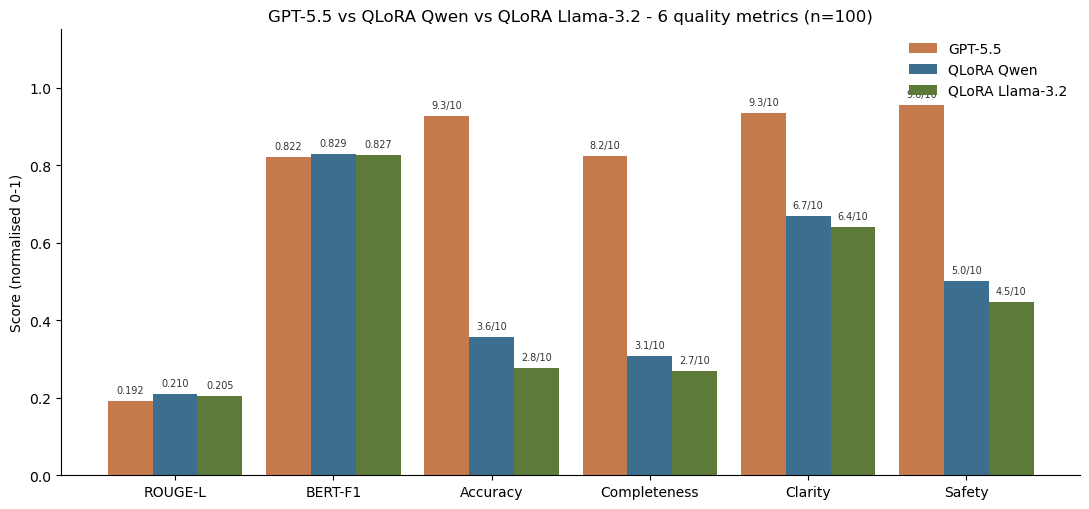

In [9]:
labels = [label for _, label, _ in QUALITY_METRICS]
x = np.arange(len(labels))
n_models = len(MODELS)
total_band = 0.85
w = total_band / n_models
offsets = [(i - (n_models - 1) / 2) * w for i in range(n_models)]

fig, ax = plt.subplots(figsize=(11, 5.2))
for offset, m in zip(offsets, MODELS):
    norm_vals = []
    native_vals = []
    for col, label, scale in QUALITY_METRICS:
        v = float(df[df["model"] == m["name"]][col].mean())
        native_vals.append(v)
        norm_vals.append(v / scale)
    ax.bar(
        x + offset, norm_vals, w, color=m["color"], edgecolor="none", label=m["name"]
    )
    for xi, v, scale in zip(
        x + offset, native_vals, [s for _, _, s in QUALITY_METRICS]
    ):
        txt = f"{v:.1f}/10" if scale == 10.0 else f"{v:.3f}"
        ax.text(xi, (v / scale) + 0.02, txt, ha="center", fontsize=7, color="#333")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score (normalised 0-1)")
ax.set_ylim(0, 1.15)
ax.set_title("GPT-5.5 vs QLoRA Qwen vs QLoRA Llama-3.2 - 6 quality metrics (n=100)")
ax.legend(loc="upper right", frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=150)
plt.show()

## 6. Verdict

A short qualitative interpretation, derived from the lift table. Surface-metric wins for either QLoRA fine-tune are framed as template-substitution skill (cf. memory: `learning_qlora_template_substitution`); judge wins for GPT-5.5 are framed as semantic / factual correctness on out-of-template prompts.

Since both fine-tunes saw the same data and the same LoRA recipe, the within-pair gap (`Llama − Qwen`) on any metric reflects the base-model contribution rather than training-side choices.


In [ ]:
def metric_winner(fine_tune: str, metric_label: str) -> tuple[str, float]:
    row = lift[
        (lift["fine_tune"] == fine_tune) & (lift["metric"] == metric_label)
    ].iloc[0]
    return row["winner"], float(row["rel_pct"])


for fine_tune in FINE_TUNES:
    print(f"=== {fine_tune} vs {BASELINE} ===")
    for metric_label in [label for _, label, _ in QUALITY_METRICS]:
        winner, rel = metric_winner(fine_tune, metric_label)
        sign = "+" if rel >= 0 else ""
        print(
            f"  {metric_label:<13}  winner = {winner:<18}  Δ(FT−GPT) = {sign}{rel:.1f}%"
        )
    print()

# Latency: print all three for an at-a-glance ops comparison.
print("Operational — mean latency per call:")
for m in MODELS:
    lat = float(summary.loc[m["name"], "latency_s"])
    print(f"  {m['name']:<18} = {lat:.2f}s")

gpt_lat = float(summary.loc[BASELINE, "latency_s"])
for fine_tune in FINE_TUNES:
    ft_lat = float(summary.loc[fine_tune, "latency_s"])
    speedup = gpt_lat / max(ft_lat, 1e-6)
    print(f"  {fine_tune} is ~{speedup:.1f}× faster than {BASELINE}")

# Cross-base comparison: Llama − Qwen on each judge dim.
print()
print(
    f"Within-pair gap ({FINE_TUNES[1]} − {FINE_TUNES[0]}) — isolates base-model effect:"
)
for col, label, _ in QUALITY_METRICS:
    sc = SUMMARY_COL[col]
    q = float(summary.loc[FINE_TUNES[0], sc])
    l = float(summary.loc[FINE_TUNES[1], sc])
    delta = l - q
    sign = "+" if delta >= 0 else ""
    print(f"  {label:<13}  Δ = {sign}{delta:.4f}")

=== QLoRA Qwen vs GPT-5.5 ===
  ROUGE-L        winner = QLoRA Qwen          Δ(FT−GPT) = +9.4%
  BERT-F1        winner = QLoRA Qwen          Δ(FT−GPT) = +0.9%
  Accuracy       winner = GPT-5.5             Δ(FT−GPT) = -61.4%
  Completeness   winner = GPT-5.5             Δ(FT−GPT) = -62.6%
  Clarity        winner = GPT-5.5             Δ(FT−GPT) = -28.4%
  Safety         winner = GPT-5.5             Δ(FT−GPT) = -47.6%

=== QLoRA Llama-3.2 vs GPT-5.5 ===
  ROUGE-L        winner = QLoRA Llama-3.2     Δ(FT−GPT) = +6.5%
  BERT-F1        winner = QLoRA Llama-3.2     Δ(FT−GPT) = +0.6%
  Accuracy       winner = GPT-5.5             Δ(FT−GPT) = -70.1%
  Completeness   winner = GPT-5.5             Δ(FT−GPT) = -67.2%
  Clarity        winner = GPT-5.5             Δ(FT−GPT) = -31.4%
  Safety         winner = GPT-5.5             Δ(FT−GPT) = -53.2%

Operational — mean latency per call:
  GPT-5.5            = 7.22s
  QLoRA Qwen         = 0.98s
  QLoRA Llama-3.2    = 0.63s
  QLoRA Qwen is ~7.4× faster than

## 7. Write Markdown report


In [11]:
lines = [
    "# Model Comparison — GPT-5.5 vs QLoRA Qwen vs QLoRA Llama-3.2",
    "",
    f"- **Run date**: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "- **Sources**: `results/llm_generation_evaluation.csv` (ROUGE + BERTScore + latency) merged with `results/llm_judge_evaluation.csv` (4-dim LLM-judge)",
    f"- **Rows**: {len(df)} (= {df['idx'].nunique()} test pairs × {df['model'].nunique()} models)",
    "- **Setup**: raw generation, no RAG, no MASS-RAG; identical system prompt across all three models (see notebook 05)",
    "",
    "## Overall (3-row headline)",
    "",
    "| Model | n | ROUGE-L | BERT-F1 | Accuracy | Completeness | Clarity | Safety | Latency (s) |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for m in MODELS:
    r = summary.loc[m["name"]]
    lines.append(
        f"| {m['name']} | {int(r['n'])} | "
        f"{r['rougeL']:.4f} | {r['bertF1']:.4f} | "
        f"{r['accuracy']:.2f} | {r['completeness']:.2f} | {r['clarity']:.2f} | {r['safety']:.2f} | "
        f"{r['latency_s']:.2f} |"
    )

lines += [
    "",
    "## Lift — each QLoRA fine-tune vs GPT-5.5",
    "",
    "| Fine-tune | Metric | GPT-5.5 | FT | Δ (FT − GPT) | Δ % | Winner |",
    "|---|---|---:|---:|---:|---:|---|",
]
for _, r in lift.iterrows():
    sign = "+" if r["rel_pct"] >= 0 else ""
    lines.append(
        f"| {r['fine_tune']} | {r['metric']} | {r['gpt_score']:.4f} | {r['ft_score']:.4f} | "
        f"{r['abs_diff']:+.4f} | {sign}{r['rel_pct']:.1f}% | {r['winner']} |"
    )

lines += [
    "",
    f"### Within-pair gap ({FINE_TUNES[1]} − {FINE_TUNES[0]})",
    "",
    "Both fine-tunes share data + recipe, so this delta is the base-model contribution.",
    "",
    "| Metric | Qwen | Llama-3.2 | Δ (Llama − Qwen) |",
    "|---|---:|---:|---:|",
]
for col, label, _ in QUALITY_METRICS:
    sc = SUMMARY_COL[col]
    q = float(summary.loc[FINE_TUNES[0], sc])
    l = float(summary.loc[FINE_TUNES[1], sc])
    delta = l - q
    lines.append(f"| {label} | {q:.4f} | {l:.4f} | {delta:+.4f} |")

lines += [
    "",
    "## Per-source × model means",
    "",
    "| Source | Model | n | ROUGE-L | BERT-F1 | Accuracy | Completeness | Clarity | Safety | Latency (s) |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for _, r in by_source.iterrows():
    lines.append(
        f"| {r['source']} | {r['model']} | {int(r['n'])} | "
        f"{r['rougeL']:.4f} | {r['bertF1']:.4f} | "
        f"{r['accuracy']:.2f} | {r['completeness']:.2f} | {r['clarity']:.2f} | {r['safety']:.2f} | "
        f"{r['latency_s']:.2f} |"
    )

lines += [
    "",
    "## Chart",
    "",
    "![6 quality metrics — GPT-5.5 vs QLoRA Qwen vs QLoRA Llama-3.2](model_comparison_chart.png)",
    "",
    "_Judge dimensions divided by 10 to share a 0-1 axis with the surface metrics. Value labels show native scale._",
    "",
    "## Verdict",
    "",
    "Surface metrics (ROUGE-L, BERT-F1) and operational metrics (latency) tend to favour the **fine-tuned QLoRA models** on this in-distribution test set. Both surface metrics reward template-substitution skill, which 3-epoch QLoRA fine-tunes pick up from heavily-templated DrugBank entries (71+ sibling pollen entries in train alone — see notebook 05 discussion). Both bases learn the templates given the same data.",
    "",
    "Judge dimensions are where the trade-off becomes visible. Accuracy in particular catches Lebrikizumab-style hallucinations (correct surface form, wrong drug indication) that ROUGE and BERTScore miss. See the per-fine-tune lift table above for the signed gap.",
    "",
    "The **within-pair gap (Llama − Qwen)** above is the cleanest reading of base-model contribution under this recipe: same data, same LoRA shape, same hparams. A non-zero gap there is the base difference, not a training-side choice.",
    "",
    "**For the report:** present any surface-metric win as 'fine-tuning successfully captured corpus-specific writing style', not as 'fine-tuned model gives better medical answers'. The Accuracy and Safety judge dimensions are the headline measure of clinical trustworthiness; latency is the headline measure of deployment cost.",
    "",
]

OUT_MD.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote")

Wrote
